<b>Когортный анализ LTV пользователей e-com сервиса британского ретейлера

Компания в основном продает уникальные подарки на все случаи жизни. Многие клиенты компании являются оптовиками

$$ LTV = \frac{Суммарный\ доход\ за\ определенный\ период}{Количество\ пользователей} $$

In [125]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [126]:
df = pd.read_csv('ecom_data.csv', encoding='1251', parse_dates=['InvoiceDate'])

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [127]:
df.dtypes

InvoiceNo                 str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

In [128]:
df['SumOrders'] = df.Quantity * df.UnitPrice
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,SumOrders
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [129]:
df = df[['InvoiceNo', 'CustomerID', 'InvoiceDate', 'SumOrders']]
df.InvoiceDate = df.InvoiceDate.dt.date
df.head()

,InvoiceNo,CustomerID,InvoiceDate,SumOrders
0,536365,17850.0,2010-12-01,15.30
1,536365,17850.0,2010-12-01,20.34
2,536365,17850.0,2010-12-01,22.00
3,536365,17850.0,2010-12-01,20.34
4,536365,17850.0,2010-12-01,20.34


In [130]:
df.head()

,InvoiceNo,CustomerID,InvoiceDate,SumOrders
0,536365,17850.0,2010-12-01,15.30
1,536365,17850.0,2010-12-01,20.34
2,536365,17850.0,2010-12-01,22.00
3,536365,17850.0,2010-12-01,20.34
4,536365,17850.0,2010-12-01,20.34


In [131]:
df.shape

(541909, 4)

Избавляемся от строк, где айди не найдено

In [132]:
df['CustomerID'].isnull().sum()

np.int64(135080)

In [133]:
df = df.dropna(subset=['CustomerID'])

In [134]:
df.shape

(406829, 4)

In [135]:
df['clients_first_order'] = df.groupby(['CustomerID'])['InvoiceDate'].transform('min')
df

,InvoiceNo,CustomerID,InvoiceDate,SumOrders,clients_first_order
0,536365,17850.0,2010-12-01,15.30,2010-12-01
1,536365,17850.0,2010-12-01,20.34,2010-12-01
2,536365,17850.0,2010-12-01,22.00,2010-12-01
3,536365,17850.0,2010-12-01,20.34,2010-12-01
4,536365,17850.0,2010-12-01,20.34,2010-12-01
...,...,...,...,...,...
541904,581587,12680.0,2011-12-09,10.20,2011-08-18
541905,581587,12680.0,2011-12-09,12.60,2011-08-18
541906,581587,12680.0,2011-12-09,16.60,2011-08-18
541907,581587,12680.0,2011-12-09,16.60,2011-08-18


In [136]:
df.dtypes

InvoiceNo                  str
CustomerID             float64
InvoiceDate             object
SumOrders              float64
clients_first_order     object
dtype: object

In [137]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['clients_first_order'] = pd.to_datetime(df['clients_first_order'])

df

,InvoiceNo,CustomerID,InvoiceDate,SumOrders,clients_first_order
0,536365,17850.0,2010-12-01,15.30,2010-12-01
1,536365,17850.0,2010-12-01,20.34,2010-12-01
2,536365,17850.0,2010-12-01,22.00,2010-12-01
3,536365,17850.0,2010-12-01,20.34,2010-12-01
4,536365,17850.0,2010-12-01,20.34,2010-12-01
...,...,...,...,...,...
541904,581587,12680.0,2011-12-09,10.20,2011-08-18
541905,581587,12680.0,2011-12-09,12.60,2011-08-18
541906,581587,12680.0,2011-12-09,16.60,2011-08-18
541907,581587,12680.0,2011-12-09,16.60,2011-08-18


In [138]:
df['Month'] = df['clients_first_order'].dt.to_period('M')
cohorts = df.groupby('Month', as_index=False).agg(customers=('CustomerID', 'nunique'), revenue=('SumOrders', 'sum'))

cohorts

,Month,customers,revenue
0,2010-12,948,4409023.950
1,2011-01,421,1001324.581
2,2011-02,380,550117.190
3,2011-03,440,594335.570
4,2011-04,299,321570.861
5,2011-05,279,271862.210
6,2011-06,235,223489.980
7,2011-07,191,135012.581
8,2011-08,167,183910.530
9,2011-09,298,227142.631


когортный LTV по месяцам жизни

In [139]:
df.head()

,InvoiceNo,CustomerID,InvoiceDate,SumOrders,clients_first_order,Month
0,536365,17850.0,2010-12-01,15.30,2010-12-01,2010-12
1,536365,17850.0,2010-12-01,20.34,2010-12-01,2010-12
2,536365,17850.0,2010-12-01,22.00,2010-12-01,2010-12
3,536365,17850.0,2010-12-01,20.34,2010-12-01,2010-12
4,536365,17850.0,2010-12-01,20.34,2010-12-01,2010-12


In [140]:
df['cohort_index'] = (df['InvoiceDate'].dt.to_period('M') - df['clients_first_order'].dt.to_period('M')).apply(lambda x:x.n)
df

,InvoiceNo,CustomerID,InvoiceDate,SumOrders,clients_first_order,Month,cohort_index
0,536365,17850.0,2010-12-01,15.30,2010-12-01,2010-12,0
1,536365,17850.0,2010-12-01,20.34,2010-12-01,2010-12,0
2,536365,17850.0,2010-12-01,22.00,2010-12-01,2010-12,0
3,536365,17850.0,2010-12-01,20.34,2010-12-01,2010-12,0
4,536365,17850.0,2010-12-01,20.34,2010-12-01,2010-12,0
...,...,...,...,...,...,...,...
541904,581587,12680.0,2011-12-09,10.20,2011-08-18,2011-08,4
541905,581587,12680.0,2011-12-09,12.60,2011-08-18,2011-08,4
541906,581587,12680.0,2011-12-09,16.60,2011-08-18,2011-08,4
541907,581587,12680.0,2011-12-09,16.60,2011-08-18,2011-08,4


In [141]:
df['cohort_index'].value_counts().sort_index()

cohort_index
0     119191
1      29147
2      27493
3      28075
4      25926
5      27576
6      24214
7      24200
8      23672
9      24075
10     21331
11     24520
12      7409
Name: count, dtype: int64

In [142]:
cohort_revenue = (df.groupby(['Month', 'cohort_index'], as_index=False)['SumOrders'].sum()).rename(columns={'SumOrders': 'revenue'})
cohort_revenue

,Month,cohort_index,revenue
0,2010-12,0,554604.02
1,2010-12,1,271616.52
2,2010-12,2,230856.22
3,2010-12,3,302509.39
4,2010-12,4,200927.98
...,...,...,...
86,2011-10,1,39209.92
87,2011-10,2,12279.46
88,2011-11,0,134231.38
89,2011-11,1,14847.53


In [143]:
cohort_revenue['cumulative_revenue'] = cohort_revenue.groupby('Month')['revenue'].cumsum()
cohort_revenue

,Month,cohort_index,revenue,cumulative_revenue
0,2010-12,0,554604.02,554604.02
1,2010-12,1,271616.52,826220.54
2,2010-12,2,230856.22,1057076.76
3,2010-12,3,302509.39,1359586.15
4,2010-12,4,200927.98,1560514.13
...,...,...,...,...
86,2011-10,1,39209.92,194140.61
87,2011-10,2,12279.46,206420.07
88,2011-11,0,134231.38,134231.38
89,2011-11,1,14847.53,149078.91


In [144]:
merge_df = cohort_revenue.merge(cohorts[['Month', 'customers']], on='Month', how = 'left')
merge_df

,Month,cohort_index,revenue,cumulative_revenue,customers
0,2010-12,0,554604.02,554604.02,948
1,2010-12,1,271616.52,826220.54,948
2,2010-12,2,230856.22,1057076.76,948
3,2010-12,3,302509.39,1359586.15,948
4,2010-12,4,200927.98,1560514.13,948
...,...,...,...,...,...
86,2011-10,1,39209.92,194140.61,352
87,2011-10,2,12279.46,206420.07,352
88,2011-11,0,134231.38,134231.38,321
89,2011-11,1,14847.53,149078.91,321


In [145]:

cohort_revenue['LTV'] = round(merge_df['cumulative_revenue'] / merge_df['customers'])
cohort_revenue

,Month,cohort_index,revenue,cumulative_revenue,LTV
0,2010-12,0,554604.02,554604.02,585.0
1,2010-12,1,271616.52,826220.54,872.0
2,2010-12,2,230856.22,1057076.76,1115.0
3,2010-12,3,302509.39,1359586.15,1434.0
4,2010-12,4,200927.98,1560514.13,1646.0
...,...,...,...,...,...
86,2011-10,1,39209.92,194140.61,552.0
87,2011-10,2,12279.46,206420.07,586.0
88,2011-11,0,134231.38,134231.38,418.0
89,2011-11,1,14847.53,149078.91,464.0


чем старше когорта, тем больше у нее доступных месяцев, поэтому справа появляются NaN у более новых когорт.

In [146]:
df_pivot = cohort_revenue.pivot(index='Month', columns='cohort_index', values='LTV')

df_pivot

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12
Month,,,,,,,,,,,,,
2010-12,585.0,872.0,1115.0,1434.0,1646.0,1985.0,2315.0,2636.0,2964.0,3456.0,3919.0,4458.0,4651.0
2011-01,483.0,617.0,765.0,863.0,1059.0,1258.0,1425.0,1598.0,1775.0,2022.0,2312.0,2378.0,NaN
2011-02,393.0,460.0,559.0,679.0,773.0,855.0,980.0,1127.0,1264.0,1423.0,1448.0,NaN,NaN
2011-03,432.0,492.0,614.0,705.0,812.0,899.0,1037.0,1177.0,1325.0,1351.0,NaN,NaN,NaN
2011-04,401.0,497.0,581.0,661.0,748.0,847.0,941.0,1054.0,1075.0,NaN,NaN,NaN,NaN
2011-05,415.0,479.0,546.0,610.0,706.0,824.0,936.0,974.0,NaN,NaN,NaN,NaN,NaN
2011-06,394.0,452.0,511.0,638.0,748.0,917.0,951.0,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,345.0,403.0,484.0,574.0,675.0,707.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,465.0,580.0,777.0,1017.0,1101.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Figure size 2000x1000 with 0 Axes>

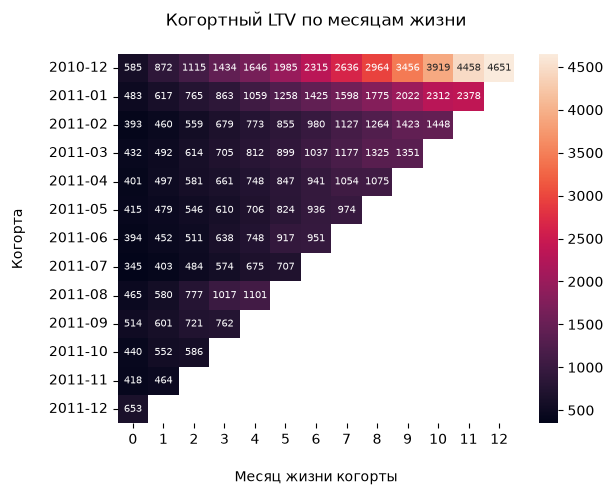

<Figure size 2000x1000 with 0 Axes>

In [147]:
sns.heatmap(df_pivot, annot=True, fmt='.0f', annot_kws={'size': 7})
plt.title('Когортный LTV по месяцам жизни\n')
plt.xlabel('\nМесяц жизни когорты')
plt.ylabel('Когорта\n')
plt.figure(figsize=(20, 10))

## Выводы

1. Декабрьские когорты демонстрируют высокий LTV в первый месяц, что может указывать на сезонность, для подтверждения нужны данные за несколько лет.
2. Когорты весны и начала лета 2011 года в среднем демонстрируют более низкий LTV на первых месяцах жизни, тогда как августовская когорта заметно выделяется более быстрым ростом.
3. Когорты примерно 2011-04–2011-07 выглядят слабее на сопоставимых горизонтах.

## Что можно сделать дальше:
1. Частота покупок. Высокий LTV из-за высоких чеков или повторных заказов?
2. Retention. Сколько клиентов вернулось через 1, 2, 3 месяца?
3. Количество заказов на клиента.
4. Данные из маркетинга, если есть, чтобы увидеть LTV\CAC.


In [148]:
## доп анализ. retention. сколько уникальных клиентов из исходной когорты совершали покупки в этом месяце жизни.

In [149]:
unique_cl_cohort = df.groupby(['Month', 'cohort_index'], as_index=False)['CustomerID'].nunique()
unique_cl_cohort

,Month,cohort_index,CustomerID
0,2010-12,0,948
1,2010-12,1,362
2,2010-12,2,317
3,2010-12,3,367
4,2010-12,4,341
...,...,...,...
86,2011-10,1,93
87,2011-10,2,46
88,2011-11,0,321
89,2011-11,1,43


In [150]:
merge_df_for_retention = unique_cl_cohort.merge(cohorts[['Month','customers']], on='Month', how='left')
merge_df_for_retention

,Month,cohort_index,CustomerID,customers
0,2010-12,0,948,948
1,2010-12,1,362,948
2,2010-12,2,317,948
3,2010-12,3,367,948
4,2010-12,4,341,948
...,...,...,...,...
86,2011-10,1,93,352
87,2011-10,2,46,352
88,2011-11,0,321,321
89,2011-11,1,43,321


In [151]:
merge_df_for_retention['retention'] = round(merge_df_for_retention['CustomerID'] / merge_df_for_retention['customers'],3)

merge_df_for_retention

,Month,cohort_index,CustomerID,customers,retention
0,2010-12,0,948,948,1.000
1,2010-12,1,362,948,0.382
2,2010-12,2,317,948,0.334
3,2010-12,3,367,948,0.387
4,2010-12,4,341,948,0.360
...,...,...,...,...,...
86,2011-10,1,93,352,0.264
87,2011-10,2,46,352,0.131
88,2011-11,0,321,321,1.000
89,2011-11,1,43,321,0.134


In [152]:
merge_df_for_retention_pivot = merge_df_for_retention.pivot(index='Month', columns='cohort_index', values='retention')
merge_df_for_retention_pivot

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12
Month,,,,,,,,,,,,,
2010-12,1.0,0.382,0.334,0.387,0.360,0.397,0.380,0.354,0.354,0.395,0.373,0.50,0.274
2011-01,1.0,0.240,0.283,0.242,0.328,0.299,0.261,0.257,0.311,0.347,0.368,0.15,NaN
2011-02,1.0,0.247,0.192,0.279,0.268,0.247,0.255,0.282,0.258,0.313,0.092,NaN,NaN
2011-03,1.0,0.191,0.255,0.218,0.232,0.177,0.264,0.239,0.289,0.089,NaN,NaN,NaN
2011-04,1.0,0.227,0.221,0.211,0.207,0.237,0.231,0.261,0.084,NaN,NaN,NaN,NaN
2011-05,1.0,0.237,0.172,0.172,0.215,0.244,0.265,0.104,NaN,NaN,NaN,NaN,NaN
2011-06,1.0,0.209,0.187,0.272,0.247,0.336,0.102,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,1.0,0.209,0.204,0.230,0.272,0.115,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,1.0,0.251,0.251,0.251,0.138,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Figure size 2000x1000 with 0 Axes>

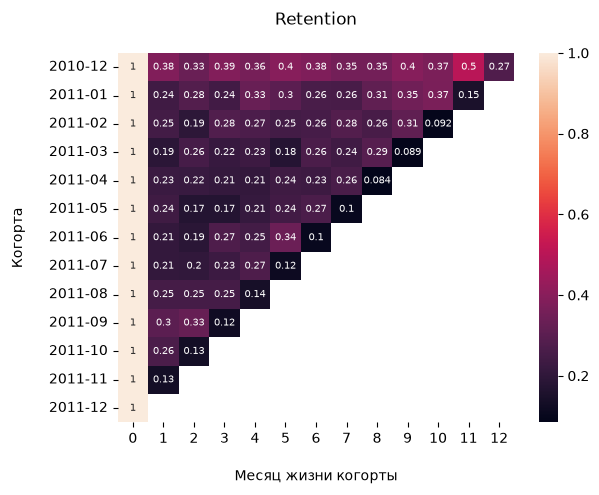

<Figure size 2000x1000 with 0 Axes>

In [153]:
sns.heatmap(merge_df_for_retention_pivot, annot=True, annot_kws={'size': 7})
plt.title('Retention\n')
plt.xlabel('\nМесяц жизни когорты')
plt.ylabel('Когорта\n')
plt.figure(figsize=(20, 10))

In [154]:
# И по карте уже видно интересное - у 2010-12 retention заметно выше многих последующих когорт; например на 1-м месяце там ~38%, тогда как у многих когорт 2011 года — около 19–30%. Это уже может частично объяснять, почему у декабрьской когорты такой высокий LTV

In [155]:
# теперь посчитаем Средний чек по когортам

In [160]:
orders = df.groupby(['InvoiceNo', 'Month', 'cohort_index'], as_index=False)['SumOrders'].sum()
orders

,InvoiceNo,Month,cohort_index,SumOrders
0,536365,2010-12,0,139.12
1,536366,2010-12,0,22.20
2,536367,2010-12,0,278.73
3,536368,2010-12,0,70.05
4,536369,2010-12,0,17.85
...,...,...,...,...
22185,C581484,2011-05,7,-168469.60
22186,C581490,2011-05,7,-32.53
22187,C581499,2010-12,12,-224.69
22188,C581568,2010-12,12,-54.75


In [161]:
# опа видим отмены, их убираем для подсчета среднего чека, поэтому:
orders_no_returns = orders[~orders['InvoiceNo'].str.startswith('C')]
orders_no_returns

,InvoiceNo,Month,cohort_index,SumOrders
0,536365,2010-12,0,139.12
1,536366,2010-12,0,22.20
2,536367,2010-12,0,278.73
3,536368,2010-12,0,70.05
4,536369,2010-12,0,17.85
...,...,...,...,...
18531,581583,2010-12,12,124.60
18532,581584,2010-12,12,140.64
18533,581585,2011-05,7,329.05
18534,581586,2010-12,12,339.20


In [172]:
mean_check = (orders_no_returns.groupby(['Month', 'cohort_index'], as_index=False)).agg({'SumOrders': 'mean'})
mean_check

,Month,cohort_index,SumOrders
0,2010-12,0,409.081350
1,2010-12,1,528.517853
2,2010-12,2,509.317645
3,2010-12,3,522.884331
4,2010-12,4,402.000524
...,...,...,...
86,2011-10,1,298.706567
87,2011-10,2,252.422000
88,2011-11,0,342.673975
89,2011-11,1,363.919286


In [163]:
mean_check_pivot = mean_check.pivot(index = 'Month', columns = 'cohort_index', values = 'SumOrders')
mean_check_pivot

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12
Month,,,,,,,,,,,,,
2010-12,409.081350,528.517853,509.317645,522.884331,402.000524,513.861709,541.454443,565.420894,610.097858,730.669985,714.548062,539.167385,553.895327
2011-01,633.337851,488.962991,424.805168,583.734959,435.925026,521.015706,479.912095,536.074161,446.393280,583.186598,505.340776,387.280000,NaN
2011-02,367.336570,303.192809,438.808901,321.007153,322.495431,281.952105,452.950472,435.238788,463.572193,387.892704,358.318519,NaN,NaN
2011-03,396.981031,344.937500,391.062695,354.772222,418.104786,410.417684,447.628613,506.861567,365.459243,274.796279,NaN,NaN,NaN
2011-04,361.500985,327.253556,345.295342,339.340845,381.365072,397.451316,372.414026,329.121250,235.188889,NaN,NaN,NaN,NaN
2011-05,378.165932,262.106143,336.923103,300.820000,332.598395,412.978375,320.011800,5975.051000,NaN,NaN,NaN,NaN,NaN
2011-06,508.684313,276.158654,314.564444,392.175513,395.892687,364.977434,323.697200,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,348.763920,310.254474,304.591765,371.244894,278.744429,276.007273,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,436.458715,502.610732,601.761017,855.579804,694.743636,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Figure size 2000x1000 with 0 Axes>

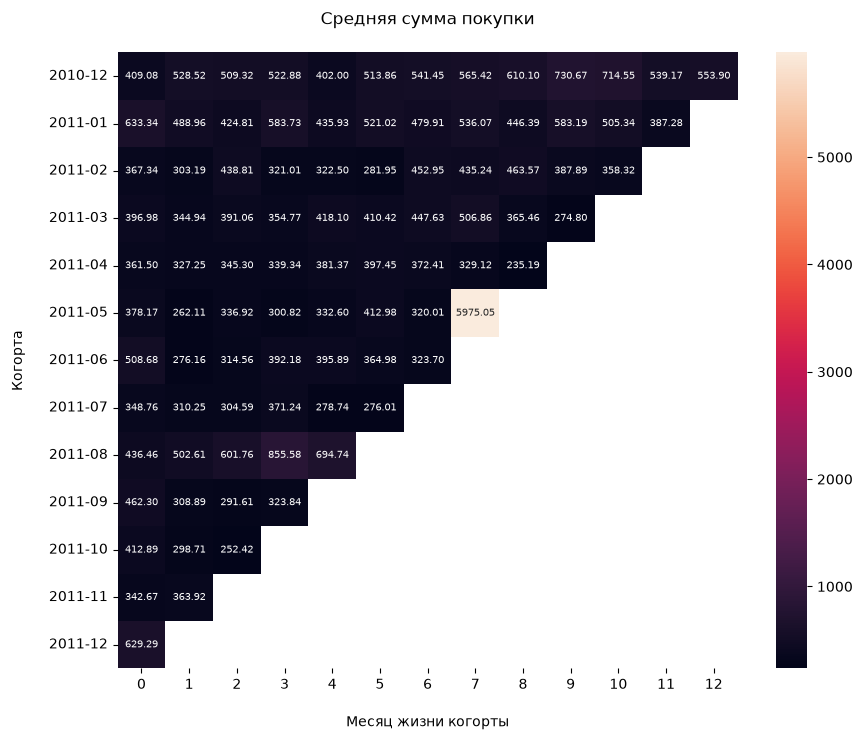

<Figure size 2000x1000 with 0 Axes>

In [183]:
plt.figure(figsize=(10, 8))
sns.heatmap(mean_check_pivot, annot=True, fmt=".2f", annot_kws={'size': 7})
plt.title('Средняя сумма покупки\n')
plt.xlabel('\nМесяц жизни когорты')
plt.ylabel('Когорта\n')
plt.figure(figsize=(20, 10))

In [159]:
# 2011-05 на 7-м месяце средний чек около 5975, что является сильным выбросом

In [159]:
# чтобы узнать почему одни когорты сильнее других посмотрим на след формулу:

# LTV = retention + частота заказов + средний чек

In [185]:
# Частота заказов = сколько заказов приходится на клиента


orders_per_customer = df.groupby('CustomerID',as_index=False)['InvoiceNo'].nunique()
orders_per_customer

,CustomerID,InvoiceNo
0,12346.0,2
1,12347.0,7
2,12348.0,4
3,12349.0,1
4,12350.0,1
...,...,...
4367,18280.0,1
4368,18281.0,1
4369,18282.0,3
4370,18283.0,16


In [187]:
orders_frequency = df.groupby(['Month', 'cohort_index', 'CustomerID'])['InvoiceNo'].nunique().reset_index(name='orders_count')
orders_frequency

,Month,cohort_index,CustomerID,orders_count
0,2010-12,0,12347.0,1
1,2010-12,0,12348.0,1
2,2010-12,0,12370.0,2
3,2010-12,0,12377.0,1
4,2010-12,0,12383.0,1
...,...,...,...,...
13670,2011-12,0,17914.0,1
13671,2011-12,0,17936.0,1
13672,2011-12,0,17942.0,1
13673,2011-12,0,18015.0,1


In [159]:
orders_frequency_mean =